In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/content/Iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.shape

(150, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [6]:
df.duplicated().sum()

np.int64(0)

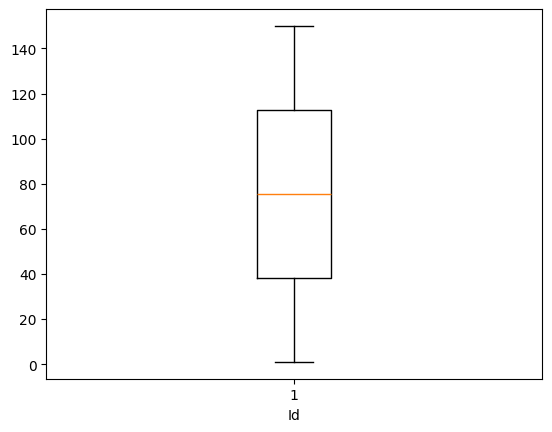

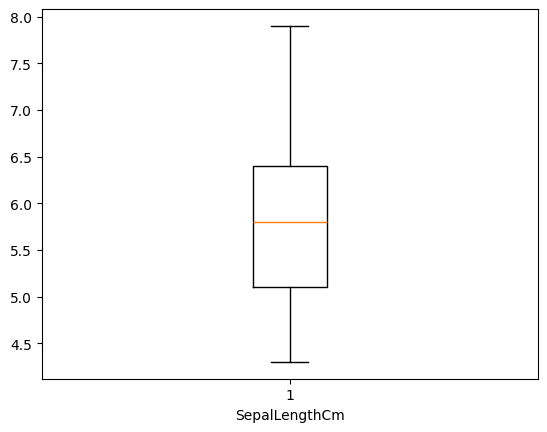

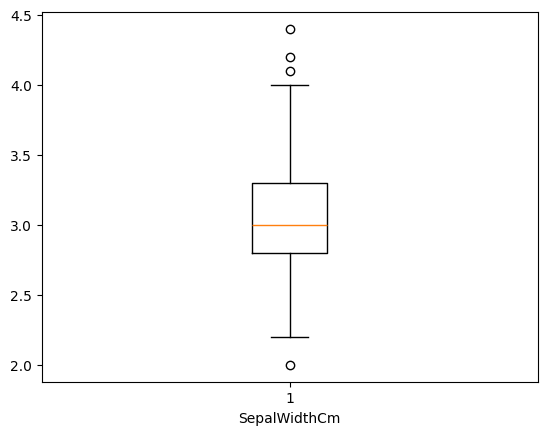

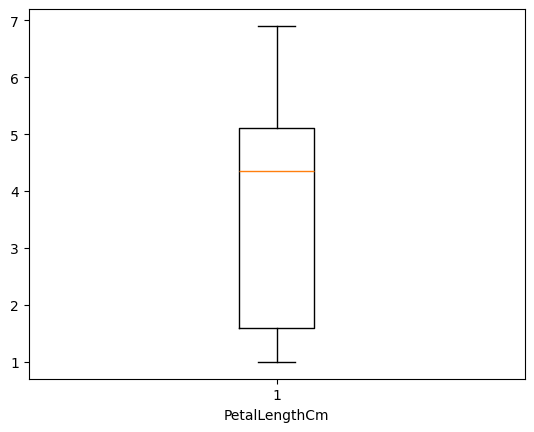

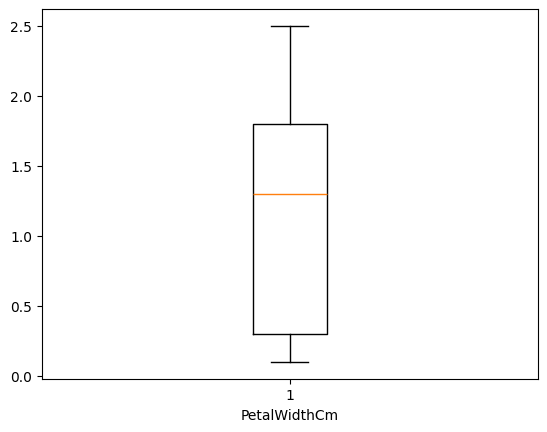

In [7]:
for i in df.columns:
  if df[i].dtype!="object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le=LabelEncoder()

In [10]:
for i in df.columns:
  if df[i].dtype=="object":
    df[i]=le.fit_transform(df[i])


In [11]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [12]:
df["Species"].value_counts()

,count
Species,
0,50
1,50
2,50


In [13]:
df.drop("Id",axis=1,inplace=True)

In [14]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [15]:
x=df.drop("Species",axis=1)
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [16]:
y=df["Species"]
y

,Species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=34)

In [19]:
xtrain.shape

(120, 4)

In [20]:
xtest.shape

(30, 4)

In [21]:
ytrain.shape

(120,)

In [22]:
ytest.shape

(30,)

##model creation


In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model=LogisticRegression()

In [25]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [26]:
pred_y=model.predict(xtest)

In [27]:
from sklearn.metrics import *

In [28]:
accuracy_score(ytest,pred_y)

1.0

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
model=RandomForestClassifier(n_estimators=100,random_state=34)

In [31]:
model.fit(xtrain,ytrain)

RandomForestClassifier(random_state=34)

In [32]:
pred_y=model.predict(xtest)

In [33]:
accuracy_score(ytest,pred_y)

0.9333333333333333

In [34]:
#from sklearn.preprocessing import StandardScaler

###scaler = StandardScaler()
#xtrain = scaler.fit_transform(xtrain)
#xtest = scaler.transform(xtest)

In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
model=KNeighborsClassifier(n_neighbors=4)

In [37]:
model.fit(xtrain,ytrain)

KNeighborsClassifier(n_neighbors=4)

In [38]:


y_pred=model.predict(xtest)

In [39]:
accuracy_score(ytest,y_pred)

0.9666666666666667

In [40]:

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(xtrain, ytrain)
    print(k, accuracy_score(ytest, knn.predict(xtest)))

1 1.0
2 0.9666666666666667
3 1.0
4 0.9666666666666667
5 0.9666666666666667
6 0.9666666666666667
7 0.9666666666666667
8 0.9333333333333333
9 0.9666666666666667
10 0.9333333333333333


In [41]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(knn, x, y, cv=5).mean())

0.9800000000000001


In [42]:
import seaborn as sns

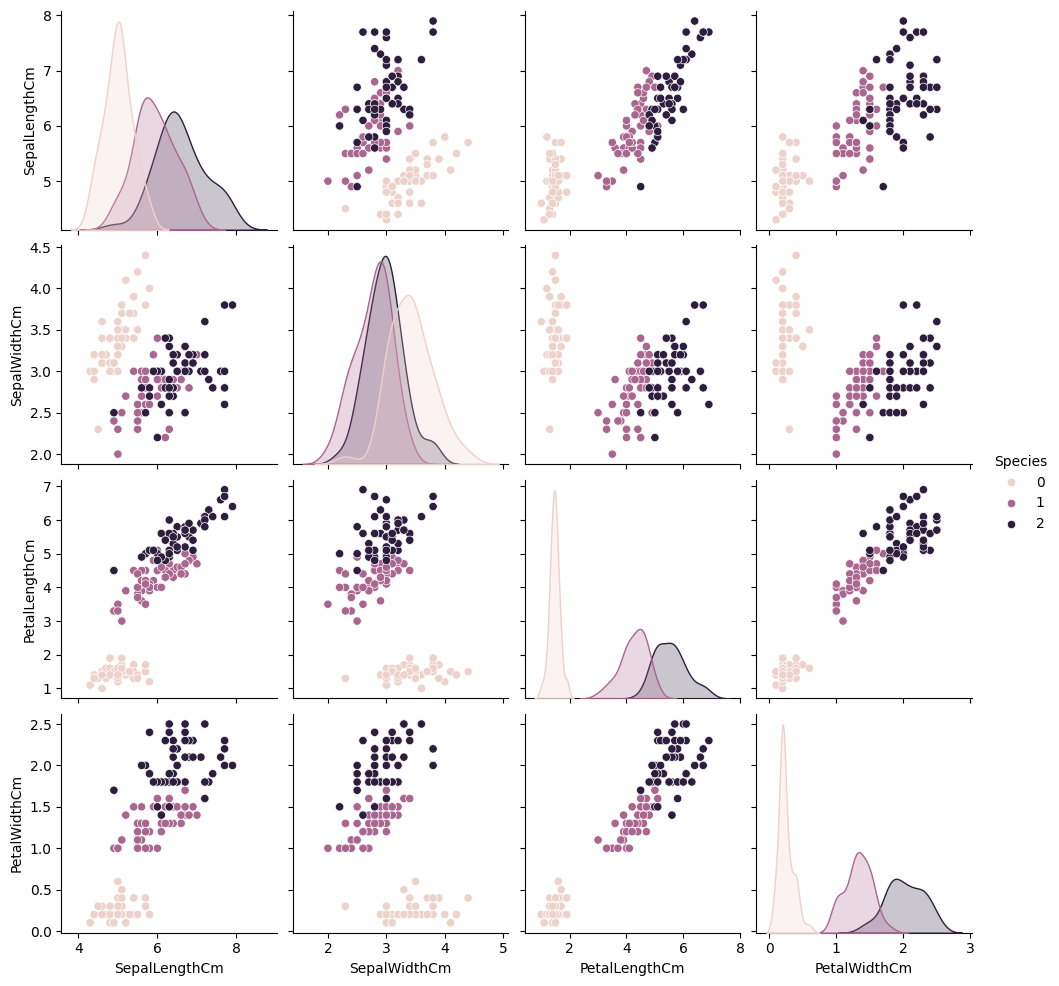

In [43]:
sns.pairplot(df, hue='Species')

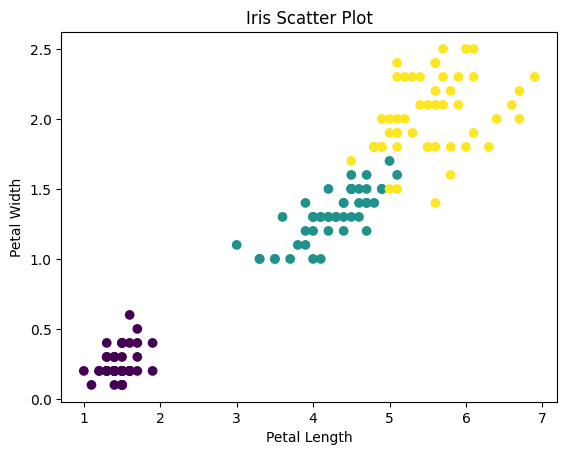

In [44]:

plt.scatter(df['PetalLengthCm'], df['PetalWidthCm'], c=df['Species'])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Scatter Plot')
plt.show()

In [45]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


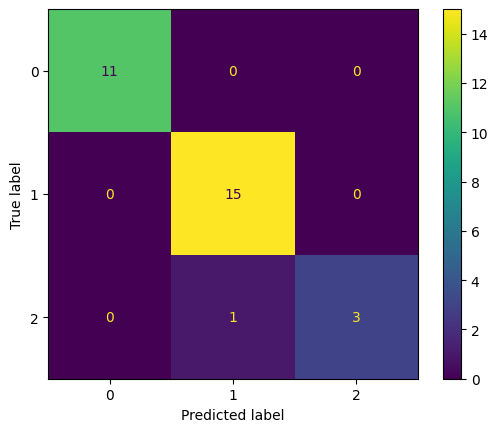

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

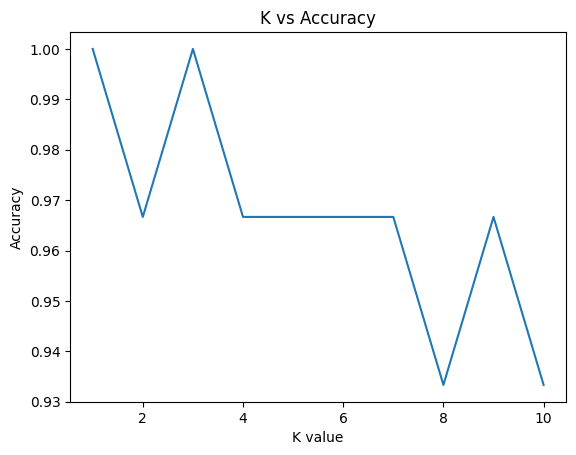

In [47]:
k_values = []
accuracies = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(xtrain, ytrain)
    acc = accuracy_score(ytest, knn.predict(xtest))
    k_values.append(k)
    accuracies.append(acc)

plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()